In [1]:
from fastai.imports import * 

In [2]:
import pandas as pd
import numpy as np


Reading the data

In [3]:
df = pd.read_csv('/kaggle/input/competitions/titanic/train.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Thayer)",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
test_df = pd.read_csv('/kaggle/input/competitions/titanic/test.csv')
test_df.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [5]:
df = df.rename(columns = {i:i.lower() for i in df.columns})
df.head()

,passengerid,survived,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Thayer)",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [6]:
df.isna().sum()

passengerid      0
survived         0
pclass           0
name             0
sex              0
age            177
sibsp            0
parch            0
ticket           0
fare             0
cabin          687
embarked         2
dtype: int64

Processing the data

In [7]:
modes = df.mode().iloc[0]
df.fillna(modes,inplace=True)  #filling the null values of feature with the mode of that particular feature

In [8]:
df.isna().sum()

passengerid    0
survived       0
pclass         0
name           0
sex            0
age            0
sibsp          0
parch          0
ticket         0
fare           0
cabin          0
embarked       0
dtype: int64

In [9]:
def process_data(df):
    df['fare'] = np.log(df['fare'] + 1)
    df['sex'] = pd.Categorical(df['sex'])
    df['embarked'] = pd.Categorical(df['embarked'])
    return df
df = process_data(df) 
df.head()

,passengerid,survived,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,2.110213,B96 B98,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Thayer)",female,38.0,1,0,PC 17599,4.280593,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,2.188856,B96 B98,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,3.990834,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,2.202765,B96 B98,S


In [10]:
def classify(df):
    target = 'survived'
    numerical = [c for c in df.select_dtypes(include=np.number).columns if c!=target]
    categorical = [c for c in df.select_dtypes(exclude=np.number).columns if c!=target]
    continuous = [feature for feature in numerical if df[feature].nunique()>20]
    discrete = [feature for feature in numerical if df[feature].nunique()<=20]
    return numerical, categorical, continuous, discrete
numerical, categorical, continuous, discrete = classify(df)    

In [11]:
print('The categorical features are:', categorical)
print('The numerical features are:', numerical)

The categorical features are: ['name', 'sex', 'ticket', 'cabin', 'embarked']
The numerical features are: ['passengerid', 'pclass', 'age', 'sibsp', 'parch', 'fare']


In [12]:
cat_features = ['sex','embarked']  #categorical features
numerical_features = ['pclass', 'age', 'sibsp', 'parch', 'fare']  #numerical features
dep_feature = ['survived']   #dependent feature or target


In [13]:
df['sex']

0        male
1      female
2      female
3      female
4        male
        ...  
886      male
887    female
888    female
889      male
890      male
Name: sex, Length: 891, dtype: category
Categories (2, object): ['female', 'male']

In [14]:
df['sex'].cat.codes

0      1
1      0
2      0
3      0
4      1
      ..
886    1
887    0
888    0
889    1
890    1
Length: 891, dtype: int8

As we can see from the above output that the value of feature sex is already stored as integers. Here integers denote the indices to represent the value of feature sex which is either female or male.

Plot to study the feature sex

[Text(0.5, 1.0, 'Histogram')]

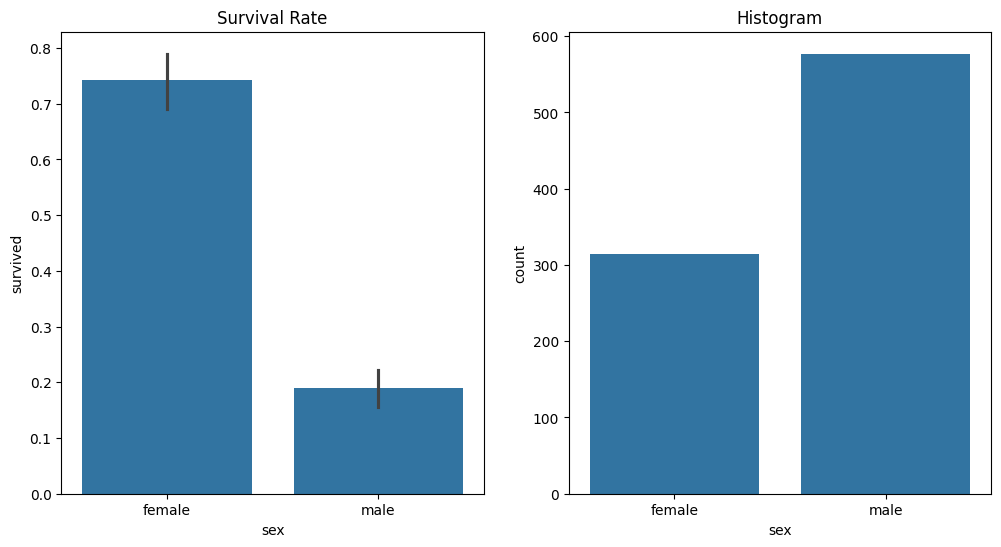

In [15]:
import seaborn as sns
fig,axes = plt.subplots(1,2,figsize=(12,6))
sns.barplot(data = df, x = 'sex', y ='survived',ax = axes[0]).set(title = 'Survival Rate')
sns.countplot(data = df, x='sex' , ax=axes[1]).set(title = 'Histogram')


We can observe from the above plot that, the feature sex is doing pretty good job at differentiating between survived and non-survived passengers, because the survival rate of female is over 70% whereas that of male is around 20%. Also , both there is pretty good difference between the number of male and female passengers.

Splitting the data into training and cross_validation dataset

In [16]:
from sklearn.model_selection import train_test_split
from numpy import random
random.seed(42)
train_df,val_df = train_test_split(df,test_size = 0.25)
#applying the categorical codes on both training as well as validation dataset
train_df[cat_features] = train_df[cat_features].apply(lambda x: x.cat.codes)
val_df[cat_features] = val_df[cat_features].apply(lambda x: x.cat.codes)

Extracting the training features as well as the target from a dataframe

In [17]:
def x_y(df):
    training_features = df[cat_features + numerical_features].copy()  #all the training features
    target = df[dep_feature]  #our target variable
    return training_features, target
train_x,train_y = x_y(train_df)
val_x, val_y = x_y(val_df)


Prediction done by the model where female is coded as 0

In [18]:
pred = val_x.sex == 0  #as female is represented as 0


In [19]:
from sklearn.metrics import mean_absolute_error
mean_absolute_error(val_y,pred)

0.21524663677130046

<Axes: xlabel='fare', ylabel='Density'>

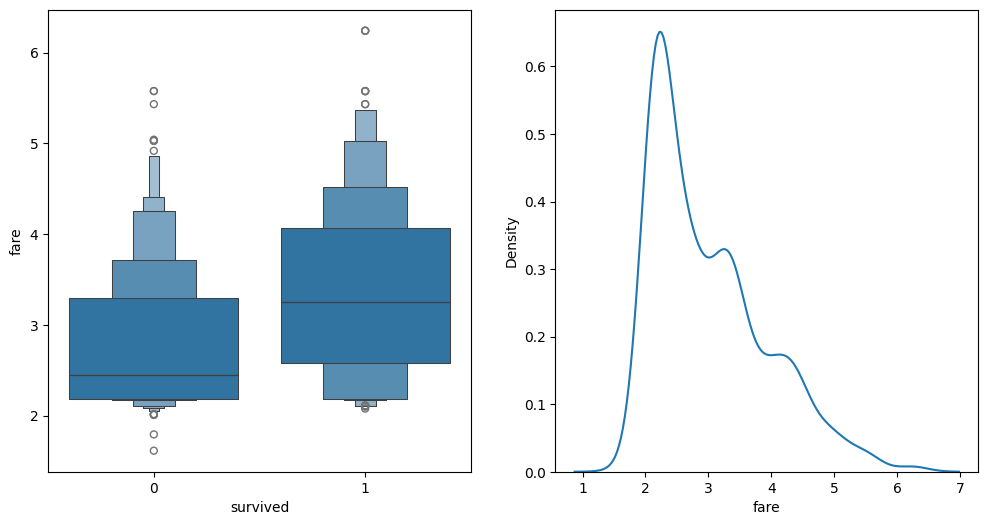

In [20]:
df_fare = train_df[train_df.fare >0]
fig,axes = plt.subplots(1,2, figsize = (12,6))
sns.boxenplot(data = df_fare , x = 'survived' , y = 'fare', ax = axes[0])
sns.kdeplot(data = df_fare , x = 'fare', ax = axes[1])



As we can observe from the above plot that, the average fare of non_survivals is around 2.5, comparatively lower than that of survivals, which is around 3.2.

Making predictions based on fare


In [21]:
preds = val_x.fare>2.5
mean_absolute_error(val_y,preds)  

0.3632286995515695

Calculation of purity on specific side based on the standard deviation. Higher the value of std, higher will be the impurity and vice-versa.

In [22]:
def side_score(side,y):
    total = side.sum()  #total number of datas in the particular side
    if total<=1:  #if the number of data is only one in the side, then we directly return 0 
        return 0
    return y[side].std() * total  #calculating std of dependent variable on specific side to measure the purity of this side


Calculation of total score or purity based on specific column split

In [23]:
def total_score(col,y,split):  #here split is the threshold value which separates the left-hand-side and right-hand-side
    lhs = col<=split  #we are assiging the column whose value is lesser than the threshold in left hand side and the opposite to right hand side
    return (side_score(lhs,y) + side_score(~lhs,y)) / len(y)

In [24]:
print('Impurity level based on splitting on feature sex is:', total_score(train_x['sex'],train_y,0.5))
print('Impurity level based on splitting on feature fare is:', total_score(train_x['fare'],train_y,2.7))


Impurity level based on splitting on feature sex is: survived    0.407875
dtype: float64
Impurity level based on splitting on feature fare is: survived    0.471809
dtype: float64


In [25]:
def iscore(features, split):
    col = train_x[features]
    return total_score(col, train_y, split)

from ipywidgets import interact
interact(features = numerical_features, split=15.5)(iscore);

interactive(children=(Dropdown(description='features', options=('pclass', 'age', 'sibsp', 'parch', 'fare'), va…

In [26]:
interact(features = cat_features, split=2)(iscore);

interactive(children=(Dropdown(description='features', options=('sex', 'embarked'), value='sex'), IntSlider(va…

Function to find the best splitting point for a feature

In [27]:
def optimal_threshold(df,feature):
    col,y = df[feature] , df['survived']
    unq = col.dropna().unique()  #extracting all the unique values of this feature from a dataframe
    scores = np.array([total_score(col,y,val) for val in unq])  #here val represents the threshold or splitting point and we are considering each unique values of feature as splitting point
    required_index = scores.argmin()  #finding the index of the lowest score or lowest impurity value
    return unq[required_index] 
optimal_threshold(train_df,'fare')    
    


np.float64(2.4390808375825834)

Calculation of optimal threshold splitting value for all features

In [28]:
total_features = cat_features + numerical_features 
storage = {feature : optimal_threshold(train_df,feature) for feature in total_features}
storage

{'sex': np.int8(0),
 'embarked': np.int8(0),
 'pclass': np.int64(2),
 'age': np.float64(6.0),
 'sibsp': np.int64(4),
 'parch': np.int64(0),
 'fare': np.float64(2.4390808375825834)}

Now we are trying to split the data based on female feature and male feature only, not sex feature

In [ ]:
total_features.remove('sex')

In [31]:
total_features

['embarked', 'pclass', 'age', 'sibsp', 'parch', 'fare']

In [32]:
ismale = train_df.sex == 1
male,female = train_df[ismale] , train_df[~ismale]  #making a dataframe based on male and female feature separately


In [33]:
male_split = {feature : optimal_threshold(male,feature) for feature in total_features}
female_split = {feature : optimal_threshold(female,feature) for feature in total_features}


In [37]:
male_split

{'embarked': np.int8(0),
 'pclass': np.int64(1),
 'age': np.float64(6.0),
 'sibsp': np.int64(4),
 'parch': np.int64(0),
 'fare': np.float64(2.803360380906535)}

In [36]:
female_split

{'embarked': np.int8(0),
 'pclass': np.int64(2),
 'age': np.float64(50.0),
 'sibsp': np.int64(4),
 'parch': np.int64(3),
 'fare': np.float64(4.256321678298823)}

In [38]:
from sklearn.tree import DecisionTreeClassifier, export_graphviz
m = DecisionTreeClassifier(max_leaf_nodes = 4).fit(train_x,train_y)
m

DecisionTreeClassifier(max_leaf_nodes=4)

In [39]:
import graphviz

def draw_tree(t, df, size=10, ratio=0.6, precision=2, **kwargs):
    s=export_graphviz(t, out_file=None, feature_names=df.columns, filled=True, rounded=True,
                      special_characters=True, rotate=False, precision=precision, **kwargs)
    return graphviz.Source(re.sub('Tree {', f'Tree {{ size={size}; ratio={ratio}', s))

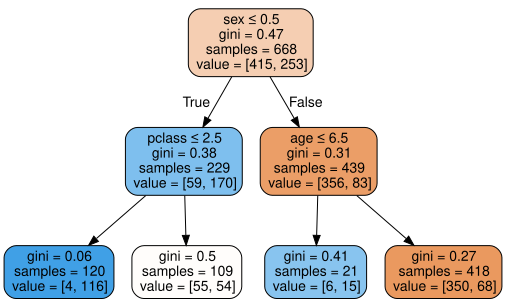

In [40]:
draw_tree(m, train_x, size=10)

Prediction done using decisiontree classifier

In [46]:
m_prediction = m.predict(val_x)
print('The mean absolute error based on cross_validation dataset is:', mean_absolute_error(val_y,m_prediction))

The mean absolute error based on cross_validation dataset is: 0.2242152466367713


Training the random forest classifier

In [47]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(100, min_samples_leaf = 5)
rf.fit(train_x,train_y) 
mean_absolute_error(val_y,rf.predict(val_x))


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


0.17937219730941703